# Rotation vs. Lorentz boost: circular and hyperbolic "rotations"

$$R(\theta) = \begin{pmatrix}\cos\theta & -\sin\theta\\ \sin\theta & \cos\theta\end{pmatrix}
\qquad
\Lambda(\beta) = \gamma\begin{pmatrix}1 & -\beta\\ -\beta & 1\end{pmatrix}, \quad
\gamma = \frac{1}{\sqrt{1-\beta^2}}$$

Both are one-parameter matrix groups: composing two rotations adds their
angles; composing two boosts adds their RAPIDITIES ($\phi=\mathrm{arctanh}\,\beta$),
not their velocities. What differs is which metric each one leaves
invariant -- $R$ preserves the Euclidean metric $\mathrm{diag}(1,1)$
(ordinary length $x^2+y^2$); $\Lambda$ preserves the Minkowski metric
$\mathrm{diag}(1,-1)$ (the spacetime interval $c^2t^2-x^2$). This notebook
verifies both claims directly, with matrices, not just states them.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np
import matplotlib.pyplot as plt

from dgs.rotation_vs_boost import (
    rotation_matrix, lorentz_boost_matrix, euclidean_metric, minkowski_metric_2d,
    preserves_metric, rotation_invariant, boost_invariant,
    rotation_composition_check, boost_composition_check,
)
print("loaded dgs.rotation_vs_boost")

loaded dgs.rotation_vs_boost


## Part 1 -- what each matrix preserves

$R^T R = I$ (orthogonal: preserves the Euclidean metric). $\Lambda^T \eta \Lambda = \eta$
for $\eta=\mathrm{diag}(1,-1)$ (preserves the Minkowski metric instead) --
checked as an explicit matrix identity, not assumed.

In [2]:
theta, beta = 0.7, 0.6
R = rotation_matrix(theta)
Lambda = lorentz_boost_matrix(beta)

print("R =\n", np.round(R, 4))
print("R^T R =\n", np.round(R.T @ R, 10), " (should be I)")
print(f"R preserves Euclidean metric: {preserves_metric(R, euclidean_metric())}")
print(f"R preserves Minkowski metric: {preserves_metric(R, minkowski_metric_2d())}")

print("\nLambda =\n", np.round(Lambda, 4))
eta = minkowski_metric_2d()
print("Lambda^T eta Lambda =\n", np.round(Lambda.T @ eta @ Lambda, 10), " (should be eta)")
print(f"Lambda preserves Minkowski metric: {preserves_metric(Lambda, eta)}")
print(f"Lambda preserves Euclidean metric: {preserves_metric(Lambda, euclidean_metric())}")

R =
 [[ 0.7648 -0.6442]
 [ 0.6442  0.7648]]
R^T R =
 [[ 1. -0.]
 [-0.  1.]]  (should be I)
R preserves Euclidean metric: True
R preserves Minkowski metric: False

Lambda =
 [[ 1.25 -0.75]
 [-0.75  1.25]]
Lambda^T eta Lambda =
 [[ 1.  0.]
 [ 0. -1.]]  (should be eta)
Lambda preserves Minkowski metric: True
Lambda preserves Euclidean metric: False


## Part 2 -- the invariant, geometrically

A rotation traces out a CIRCLE (constant $x^2+y^2$) as $\theta$ sweeps; a
boost traces out a HYPERBOLA (constant $c^2t^2-x^2$) as $\beta$ sweeps -- the
same picture that gives "hyperbolic rotation" its name.

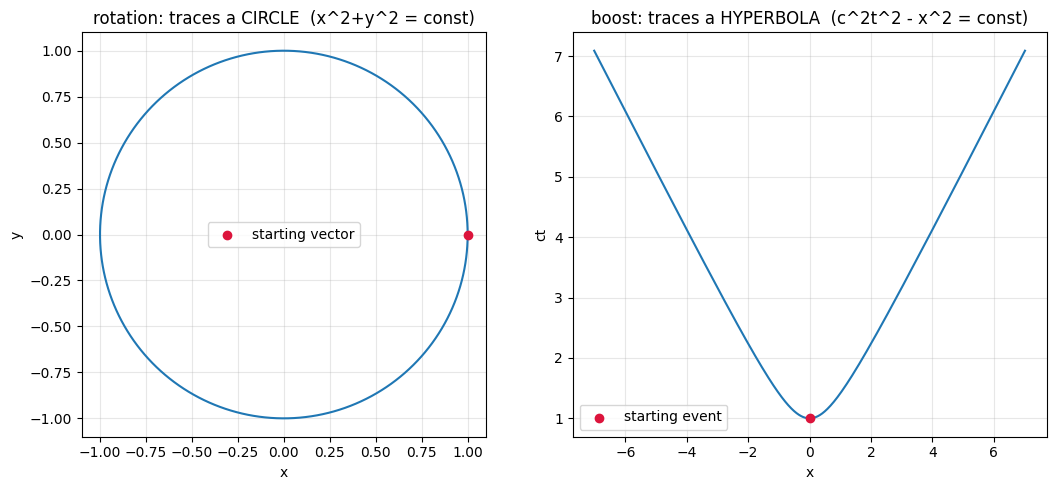

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(11, 5))

v0 = np.array([1.0, 0.0])
thetas = np.linspace(0, 2*np.pi, 200)
circle = np.array([rotation_matrix(t) @ v0 for t in thetas])
axs[0].plot(circle[:, 0], circle[:, 1])
axs[0].scatter(*v0, color='crimson', zorder=5, label='starting vector')
axs[0].set_aspect('equal'); axs[0].set_xlabel('x'); axs[0].set_ylabel('y')
axs[0].set_title('rotation: traces a CIRCLE  (x^2+y^2 = const)')
axs[0].legend(); axs[0].grid(alpha=0.3)

event0 = np.array([1.0, 0.0])  # (ct, x) at rest
betas = np.linspace(-0.99, 0.99, 200)
hyperbola = np.array([lorentz_boost_matrix(b) @ event0 for b in betas])
axs[1].plot(hyperbola[:, 1], hyperbola[:, 0])
axs[1].scatter(event0[1], event0[0], color='crimson', zorder=5, label='starting event')
axs[1].set_xlabel('x'); axs[1].set_ylabel('ct')
axs[1].set_title('boost: traces a HYPERBOLA  (c^2t^2 - x^2 = const)')
axs[1].legend(); axs[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Part 3 -- what does NOT survive the boost

Boosting the SAME event and computing Euclidean length $c^2t^2+x^2$ instead
of the Minkowski interval shows it is NOT conserved -- the point of using a
different metric in the first place.

In [4]:
result = boost_invariant(beta=0.6, ct=5.0, x=3.0)
print(f"Minkowski  c^2t^2-x^2:  before={result['minkowski_before']:.4f}  after={result['minkowski_after']:.4f}  (conserved)")
print(f"Euclidean  c^2t^2+x^2:  before={result['euclidean_before']:.4f}  after={result['euclidean_after']:.4f}  (NOT conserved)")
print(f"\ncross-check against dgs.special_relativity.four_vector_boost (independent code path):")
print(f"  invariant_orig={result['cross_check_invariant_orig']:.4f}  invariant_prime={result['cross_check_invariant_prime']:.4f}")

Minkowski  c^2t^2-x^2:  before=16.0000  after=16.0000  (conserved)
Euclidean  c^2t^2+x^2:  before=34.0000  after=16.0000  (NOT conserved)

cross-check against dgs.special_relativity.four_vector_boost (independent code path):
  invariant_orig=16.0000  invariant_prime=16.0000


## Part 4 -- composition: angles add, rapidities add (not velocities)

$R(\theta_1)R(\theta_2)=R(\theta_1+\theta_2)$ and
$\Lambda(\beta_1)\Lambda(\beta_2)=\Lambda(\beta_{combined})$, where
$\beta_{combined}$ is the relativistic velocity-addition formula (reused
from `dgs/special_relativity.py`, not re-derived) -- NOT $\beta_1+\beta_2$.
Composing boosts adds RAPIDITIES $\phi=\mathrm{arctanh}\,\beta$ instead,
exactly mirroring how composing rotations adds angles.

R(0.3) @ R(0.5) == R(0.8):  True

Lambda(0.3) @ Lambda(0.5) == Lambda(beta_combined):  True
beta_combined = 0.6957   (NOT 0.3+0.5 = 0.8)
beta_combined matches tanh(rapidity1 + rapidity2):  True


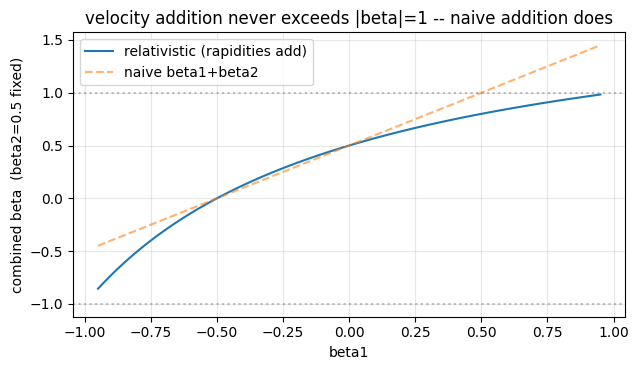

In [5]:
rc = rotation_composition_check(0.3, 0.5)
print(f"R(0.3) @ R(0.5) == R(0.8):  {rc['matches']}")

bc = boost_composition_check(0.3, 0.5)
print(f"\nLambda(0.3) @ Lambda(0.5) == Lambda(beta_combined):  {bc['matches']}")
print(f"beta_combined = {bc['beta_combined']:.4f}   (NOT 0.3+0.5 = 0.8)")
print(f"beta_combined matches tanh(rapidity1 + rapidity2):  {bc['rapidities_add']}")

# visualize: velocity addition vs naive sum, across a range of beta1 with beta2=0.5 fixed
beta1_range = np.linspace(-0.95, 0.95, 100)
combined = [boost_composition_check(b1, 0.5)['beta_combined'] for b1 in beta1_range]
naive = beta1_range + 0.5

plt.figure(figsize=(6.5, 3.8))
plt.plot(beta1_range, combined, label='relativistic (rapidities add)')
plt.plot(beta1_range, naive, '--', alpha=0.6, label='naive beta1+beta2')
plt.axhline(1.0, color='gray', ls=':', alpha=0.5); plt.axhline(-1.0, color='gray', ls=':', alpha=0.5)
plt.xlabel('beta1'); plt.ylabel('combined beta  (beta2=0.5 fixed)')
plt.title('velocity addition never exceeds |beta|=1 -- naive addition does')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

## Summary

| | Rotation $R(\theta)$ | Boost $\Lambda(\beta)$ |
|---|---|---|
| Functions | $\cos,\sin$ | $\cosh,\sinh$ (via $\gamma,\gamma\beta$) |
| Parameter | angle $\theta$ | rapidity $\phi=\mathrm{arctanh}\,\beta$ |
| Preserves | $x^2+y^2$ (Euclidean) | $c^2t^2-x^2$ (Minkowski) |
| Traces out | a circle | a hyperbola |
| Composition | $\theta_1+\theta_2$ | $\phi_1+\phi_2$ (NOT $\beta_1+\beta_2$) |
| Group | SO(2) | SO(1,1) |

Everything above is `dgs/rotation_vs_boost.py`, cross-checked against
`dgs/special_relativity.py`'s independently-implemented `four_vector_boost`
and `velocity_addition` rather than asserted on its own.